# FIRAS dark-photon limits: which statistic, and why ours is stronger than CCJ24

Figure 8 of the paper sets a 95% CL FIRAS upper limit on the dark-photon
kinetic mixing $\epsilon(m_{A'})$. It is 13–16% stronger in $\epsilon$ than the
curve of [Chluba, Cyr & Johnson (2024)](https://arxiv.org/abs/2409.12115)
(CCJ24, Fig. 8). This notebook shows where that gap comes from.

The short answer: the paper quotes $\hat a + 1.645\,\sigma_a$ without flooring
the best-fit amplitude $\hat a$ at zero, and FIRAS fluctuates about $0.45\sigma$
low along the dark-photon shape. Flooring alone moves our limit onto the CCJ24
curve. The temperature treatment, the covariance matrix, and the data column
each change the limit by 2% or less. The full audit is in
`dev/audit/ccj24_limit_gap.md`.

We have two copies of the CCJ24 curve:

- **author-supplied**: `dev/AxionLimits/limit_data/DarkPhoton/COBEFIRAS_Chluba.txt`
  (from the AxionLimits repository);
- **hand-digitized**: `dev/data/cosmotherm_dp_lims.csv`.

They disagree by up to 3.3% in $\epsilon$ below $1.6\times10^{-7}$ eV and up to
4.0% below $3\times10^{-5}$ eV (cell below). Any claim that one
statistic reproduces CCJ24 "better" than another at the 1–3% level is below
this floor.

**Templates.** No PDE runs happen here. The PDE templates are cached at four
masses only (`dev/scripts/ccj24_gap/tmpl_*.npz`). For the full mass grid we use
the CCJ24 closed form (their Eq. 25), $\Delta n/\gamma_{\rm con} =
J_{\rm bb}(z_{\rm con})\,D(x)$ after the temperature-shift part is removed.
With a fixed statistic, it gives the same limit as the PDE template to 0.3% up to
$m_{A'} = 1.6\times10^{-7}$ eV, and a 9% weaker one at $3.6\times10^{-6}$ eV,
deep in the $\mu$ era. The shape $D(x)$ does not depend on mass, so every
ratio between two statistics is flat along this grid. The PDE points show how
it changes in the $\mu$ era.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.stats import norm, chi2 as chi2_dist

from spectroxide import apply_style, g_bb, planck, G1_PLANCK, G2_PLANCK
from spectroxide.dark_photon import gc_per_epsilon_sq
from spectroxide.firas import FIRASData
from spectroxide.plot_params import C, DOUBLE_COL, LW, LW_THICK, LEGEND_SIZE

apply_style()
ROOT = Path.cwd().parent.parent
FIG_DIR = ROOT / 'notebooks' / 'figures'

# SI constants (exact, SI 2019)
H_PL, K_B, C_LIGHT = 6.62607015e-34, 1.380649e-23, 2.99792458e8

firas = FIRASData()
NU = firas.freq_cm * C_LIGHT * 100                     # Hz
PREF = 2 * H_PL * NU**3 / C_LIGHT**2 / 1e-23           # kJy/sr per unit Delta n
I_OBS = firas.spectrum_MJy * 1e3                       # FIRAS column 2 [kJy/sr]
RESID = firas.residual_kJy                             # FIRAS column 3 [kJy/sr]
SIGMA = firas.sigma_kJy
CINV = {'full': firas.cov_inv, 'diag': np.diag(1 / SIGMA**2)}
DUST = firas.galactic_template_kJy()                   # nu^2 B(nu, 9 K)
T0 = 2.725                                             # K, FIRAS reference
Z95 = norm.ppf(0.95)                                   # 1.6449
N_FREQ = len(NU)

# The two copies of the CCJ24 curve
ref_auth = np.loadtxt(ROOT / 'dev/AxionLimits/limit_data/DarkPhoton/COBEFIRAS_Chluba.txt')
ref_dig = np.loadtxt(ROOT / 'dev/data/cosmotherm_dp_lims.csv', delimiter=',')


def ref_eps(tab, m):
    '''Log-log interpolation of a reference curve; NaN outside its range.'''
    return 10 ** np.interp(np.log10(m), np.log10(tab[:, 0]), np.log10(tab[:, 1]),
                           left=np.nan, right=np.nan)


# Compare the copies over the mass range used below (both curves turn up
# steeply above ~1e-4 eV, where small mass offsets give huge ratios).
for m_lo, m_hi in ((1.5e-12, 1.6e-7), (1.5e-12, 3.1e-5)):
    mm = np.geomspace(m_lo, m_hi, 400)
    r_ref = ref_eps(ref_dig, mm) / ref_eps(ref_auth, mm)
    print(f'hand-digitized / author-supplied, {m_lo:.1e}-{m_hi:.1e} eV: '
          f'[{r_ref.min():.4f}, {r_ref.max():.4f}]')

hand-digitized / author-supplied, 1.5e-12-1.6e-07 eV: [0.9786, 1.0332]
hand-digitized / author-supplied, 1.5e-12-3.1e-05 eV: [0.9790, 1.0396]


## The fit as linear algebra

Every statistic below starts from the same generalized least-squares (GLS)
fit. Write the FIRAS data as a 43-vector $\vec d$ in kJy/sr and fit

$$\vec d = a\,\vec S + b\,\vec G_{\rm bb} + g\,\vec D_{\rm dust} + \text{noise},
\qquad \text{noise}\sim\mathcal N(0, \mathsf C),$$

where $\vec S = (2h\nu^3/c^2)\,\mathcal T(x)$ is the dark-photon template per
unit $\gamma_{\rm con}$, $\vec G_{\rm bb}$ is a temperature shift, and
$\vec D_{\rm dust}\propto\nu^2B(\nu, 9\,{\rm K})$. With the design matrix
$\mathsf A = [\vec S, \vec G_{\rm bb}, \vec D_{\rm dust}]$,

$$\hat\theta = (\mathsf A^{\rm T}\mathsf C^{-1}\mathsf A)^{-1}
\mathsf A^{\rm T}\mathsf C^{-1}\vec d,\qquad
\sigma_a^2 = \big[(\mathsf A^{\rm T}\mathsf C^{-1}\mathsf A)^{-1}\big]_{11}.$$

The first component is $\hat a$, and $\sigma_a$ already includes the
marginalization over temperature and dust. The model is linear in $a$, so
$\chi^2(a) = \chi^2_{\rm min} + (a - \hat a)^2/\sigma_a^2$ exactly after
profiling $b$ and $g$. Every limit below is then a function of two numbers,
$k \equiv \hat a/\sigma_a$ and $\sigma_a$ (plus $\chi^2_{\rm min}$ for the
goodness-of-fit test): $a_{95} = u(k)\,\sigma_a$. Since
$\gamma_{\rm con}\propto\epsilon^2$, a ratio $r$ of amplitude limits is a
ratio $\sqrt r$ in $\epsilon$.

The two fit setups differ in three inputs:

| setup | covariance $\mathsf C$ | data $\vec d$ | temperature |
|---|---|---|---|
| **paper** (Fig. 8) | full $43\times43$ | column 2 $-\,B(\nu, T)$ | $T$ floated |
| **CCJ24** (Sect. 5) | diagonal $\sigma_i^2$ | column 3 residual | fixed $T_0 = 2.725$ K, $\vec G_{\rm bb}$ fitted |

With $T$ floated, the paper fit first minimizes $\chi^2$ over $T$ with columns
$[\vec S(x(T)), \vec D_{\rm dust}]$, then evaluates $\hat a$, $\sigma_a$ at
$T_{\rm best}$ with all three columns. This is what
`FIRASData.profile_limit_floating_T` does.

In [2]:
def x_of(T):
    return H_PL * NU / (K_B * T)


def data_vec(T, column):
    '''FIRAS residual with respect to B(nu, T) [kJy/sr].

    column 2: I_obs - B(T).  column 3: the published residual (exact at T0),
    shifted linearly to T.  The two differ by FIRAS rounding only.
    '''
    x = x_of(T)
    if column == 2:
        return I_OBS - PREF / np.expm1(x)
    return RESID + PREF * (1 / np.expm1(x_of(T0)) - 1 / np.expm1(x))


def gls(cols, d, Cinv):
    '''GLS fit. Returns (first coefficient, its 1-sigma error, chi2_min).'''
    A = np.column_stack(cols)
    fisher_inv = np.linalg.inv(A.T @ Cinv @ A)
    theta = fisher_inv @ (A.T @ Cinv @ d)
    r = d - A @ theta
    return theta[0], np.sqrt(fisher_inv[0, 0]), float(r @ Cinv @ r)


def fit(tmpl, cov='full', column=2, float_T=True):
    '''Fit amplitude of template tmpl(x) [Delta n per unit gamma_con].

    Returns dict(a, s, k, chi2_min, T). chi2_min has N_FREQ - 3 dof.
    '''
    Cinv = CINV[cov]
    if float_T:
        def chi2_T(T):
            x = x_of(T)
            return gls([PREF * tmpl(x), DUST], data_vec(T, column), Cinv)[2]
        T = minimize_scalar(chi2_T, bounds=(2.720, 2.732), method='bounded',
                            options={'xatol': 1e-9}).x
    else:
        T = T0
    x = x_of(T)
    a, s, c2 = gls([PREF * tmpl(x), PREF * g_bb(x), DUST], data_vec(T, column), Cinv)
    return dict(a=a, s=s, k=a / s, chi2_min=c2, T=T)


SETUPS = {
    'paper': dict(cov='full', column=2, float_T=True),
    'ccj24': dict(cov='diag', column=3, float_T=False),
}

## The statistics

Each statistic is a function $u$ with $a_{95} = u\,\sigma_a$.

**(a) Paper: unfloored.** $u = k + 1.645$. This is also where
$\chi^2(a) - \chi^2_{\rm min} = 2.71$ with $\chi^2_{\rm min}$ taken at the
unconstrained best fit, including $\hat a < 0$.

**(b) Floored.** $u = \max(k, 0) + 1.645$. When $\hat a < 0$, the limit equals
the sensitivity $1.645\,\sigma_a$ and does not depend on the data. For $k<0$
the $\epsilon$ ratio paper/floored is $\sqrt{(k + 1.645)/1.645}$.

**(c) Bayesian, flat prior on $\gamma_{\rm con}\ge 0$.** The posterior is a
Gaussian truncated at zero. Solving
$\int_0^{a_{95}} p\,da = 0.95\int_0^\infty p\,da$ gives
$u = k + \Phi^{-1}\big(1 - 0.05\,\Phi(k)\big)$. For a Gaussian likelihood this
equals the asymptotic CL$_s$ limit (Read 2002).

**(d) $\Delta\chi^2$ with the physical boundary.** The minimum is taken over
$a \ge 0$: for $k<0$, $\chi^2(a) - \chi^2(0) = t$ gives $u = k + \sqrt{k^2 + t}$.
We use $t = 2.71$ (one-sided 95%) and $t = 3.84$ (two-sided 95%).

**(e) Goodness of fit (GoF).** Reject a fixed $a$ when its own $\chi^2(a)$,
minimized over the nuisance parameters only, exceeds the 95th percentile of
$\chi^2_{\nu}$ with $\nu = 43 - 2 = 41$ (the hypothesis fixes $a$; $T$ and dust
are fitted). Because $\chi^2(a) = \chi^2_{\rm min} + (a-\hat a)^2/\sigma_a^2$,
$u = k + \sqrt{\chi^2_{41,0.95} - \chi^2_{\rm min}}$.

In [3]:
def u_paper(k):
    return k + Z95


def u_floor(k):
    return max(k, 0.0) + Z95


def u_bayes(k):
    return k + norm.ppf(1 - 0.05 * norm.cdf(k))


def u_dchi2(k, t):
    return k + np.sqrt(k * k + t) if k < 0 else k + np.sqrt(t)


CHI2_CRIT = chi2_dist.ppf(0.95, N_FREQ - 2)   # 56.94


def u_gof(k, chi2_min, crit=CHI2_CRIT):
    return k + np.sqrt(crit - chi2_min) if crit > chi2_min else np.nan


print(f'chi2_41 95th percentile = {CHI2_CRIT:.2f}')

chi2_41 95th percentile = 56.94


### The earlier GoF implementation

`notebooks/observational/dp_firas_method_comparison.ipynb` implemented a
"strict single-hypothesis goodness-of-fit" reading. It is copied verbatim
below (`gof_limit_old`). It gave limits 1.33 times the CCJ24 curve (median).
We check four properties.

1. *Nuisance parameters.* It projects $\vec G_{\rm bb}$ and dust out of the
   model $\vec S$ but not out of the data. So it computes
   $|\vec d - a\vec S_\perp|^2 = |\vec d_\perp - a\vec S_\perp|^2 + |\vec d_\parallel|^2$,
   which exceeds the nuisance-minimized $\chi^2$ by $|\vec d_\parallel|^2$.
   On column 3 this term is 0.01, because FIRAS already fitted $T$ to make that
   column. On column 2 at $T_0$ it would be 3.8 and the test would be wrong.
2. *Degrees of freedom.* $43 - 2 = 41$ is correct.
3. *Threshold.* The 95th percentile of $\chi^2_{41}$, applied to
   $\chi^2(a)$ itself, not to $\chi^2(a) - \chi^2_{\rm min}$. That is the right
   form for a GoF test.
4. *Covariance.* It uses diagonal errors. The FIRAS channels are correlated,
   so this $\chi^2$ does not follow $\chi^2_{41}$. We simulate its
   distribution below.

The correct version fits the nuisance parameters explicitly and uses the full
covariance. Then $\chi^2(a)$ follows $\chi^2_{41}$ under the hypothesis.

In [4]:
def gof_limit_old(template_dn_func, cl=0.95):
    '''Verbatim logic of gof_limit in dp_firas_method_comparison.ipynb.'''
    S = PREF * template_dn_func(x_of(T0))
    G = PREF * g_bb(x_of(T0))
    w = 1.0 / SIGMA**2
    dot = lambda a, b: float(np.sum(a * w * b))
    m2 = np.array([[dot(G, G), dot(DUST, G)], [dot(G, DUST), dot(DUST, DUST)]])
    dT, dg = np.linalg.solve(m2, [dot(S, G), dot(S, DUST)])
    S_perp = S - dT * G - dg * DUST
    d = RESID
    A = dot(S_perp, S_perp)
    B = dot(d, S_perp)
    chi2_null = dot(d, d)
    chi2_crit = chi2_dist.ppf(cl, N_FREQ - 2)
    return (B + np.sqrt(B**2 + A * (chi2_crit - chi2_null))) / A


# Nuisance part of the data, |d_par|^2, for columns 3 and 2 at T0
for col in (3, 2):
    d = data_vec(T0, col)
    for cov in ('diag', 'full'):
        Ci = CINV[cov]
        N = np.column_stack([PREF * g_bb(x_of(T0)), DUST])
        d_par = N @ np.linalg.solve(N.T @ Ci @ N, N.T @ Ci @ d)
        print(f'column {col}, {cov:4s} cov: |d|^2 = {d @ Ci @ d:6.2f}, '
              f'|d_par|^2 = {d_par @ Ci @ d_par:5.2f}')

# Distribution of the diagonal-error chi2 when the noise has the full covariance
rng = np.random.default_rng(20260922)
N = np.column_stack([PREF * g_bb(x_of(T0)), DUST])
Cd = CINV['diag']
proj = np.eye(N_FREQ) - N @ np.linalg.solve(N.T @ Cd @ N, N.T @ Cd)
noise = proj @ (np.linalg.cholesky(firas.cov) @ rng.standard_normal((N_FREQ, 400_000)))
q = np.einsum('ij,ij->j', noise, Cd @ noise)
CHI2_CRIT_DIAG = np.percentile(q, 95)
print(f'\ndiagonal chi2 under the full FIRAS covariance: mean {q.mean():.1f}, '
      f'95th percentile {CHI2_CRIT_DIAG:.1f} (chi2_41 gives {CHI2_CRIT:.1f})')

column 3, diag cov: |d|^2 =  45.03, |d_par|^2 =  0.00
column 3, full cov: |d|^2 =  48.74, |d_par|^2 =  0.01
column 2, diag cov: |d|^2 =  49.19, |d_par|^2 =  4.09
column 2, full cov: |d|^2 =  52.58, |d_par|^2 =  3.77

diagonal chi2 under the full FIRAS covariance: mean 40.8, 95th percentile 58.5 (chi2_41 gives 56.9)


## FIRAS's own $\chi^2_{\rm min}$

A GoF test is weak when the data fit much better than expected, because then
$\chi^2_{41,0.95} - \chi^2_{\rm min}$ is large. FIRAS does not fit
unusually well here. With the three-column fit, $\chi^2_{\rm min}$ has
$43 - 3 = 40$ degrees of freedom.

In [5]:
def D_shape(x):
    '''CCJ24 Eq. 26: number-conserving dark-photon distortion.'''
    return (G1_PLANCK / (3 * G2_PLANCK)) * g_bb(x) - planck(x) / x


for name, kw in SETUPS.items():
    f = fit(D_shape, **kw)
    print(f'{name:5s}: chi2_min = {f["chi2_min"]:.2f} for 40 dof '
          f'(chi2/dof = {f["chi2_min"] / 40:.2f}, p = {chi2_dist.sf(f["chi2_min"], 40):.2f}); '
          f'chi2_crit - chi2_min = {CHI2_CRIT - f["chi2_min"]:.1f}  '
          f'-> GoF u - k = {np.sqrt(CHI2_CRIT - f["chi2_min"]):.2f} vs 1.645')

paper: chi2_min = 48.59 for 40 dof (chi2/dof = 1.21, p = 0.17); chi2_crit - chi2_min = 8.4  -> GoF u - k = 2.89 vs 1.645
ccj24: chi2_min = 44.89 for 40 dof (chi2/dof = 1.12, p = 0.27); chi2_crit - chi2_min = 12.1  -> GoF u - k = 3.47 vs 1.645


$\chi^2_{\rm min}/{\rm dof}$ is 1.2 (full covariance) and 1.1 (diagonal), so
FIRAS is not far below its expected $\chi^2$. The GoF test is weak for a
different reason. It sets its limit $\sqrt{\chi^2_{41,0.95} - \chi^2_{\rm min}}
\approx 2.9$–$3.5\,\sigma_a$ above $\hat a$, against $1.645\,\sigma_a$ for a
likelihood ratio. The $\chi^2_{41}$ threshold spends its 5% on 41 directions,
and only one of them is the signal. A GoF test is valid, but it is not an
upper-limit method (Cowan et al. 2011, Sect. 3).

## Templates

The four cached PDE templates are the $G_{\rm bb}$-stripped PDE outputs per
unit $\gamma_{\rm con}$, run at $\epsilon$ equal to the hand-digitized CCJ24
limit (`dev/scripts/ccj24_gap/run_pde.py`). The analytic template is
$J_{\rm bb}(z_{\rm con})D(x)$ with $J_{\rm bb} = e^{-(z/z_\mu)^{5/2}}$,
$z_\mu = 1.98\times10^6$. We use it where CCJ24 derived it: $z_{\rm con}<z_\mu$
and $\gamma_{\rm con}<0.03$ at the limit. The mass grid is the 80-mass grid of
the cached paper curve `dev/data/dp_firas_pde_limits.npz`, so we can check the
paper statistic against it point by point.

In [6]:
GAP_DIR = ROOT / 'dev' / 'scripts' / 'ccj24_gap'
pde = []
for f in sorted(GAP_DIR.glob('tmpl_*.npz'), key=lambda p: float(p.stem[5:])):
    t = np.load(f)
    pde.append(dict(m=float(t['m']), z=float(t['zr']), gpe2=float(t['gpe2']),
                    tmpl=lambda x, _x=t['x'], _d=t['dn_per_gc']: np.interp(x, _x, _d)))

cache = np.load(ROOT / 'dev' / 'data' / 'dp_firas_pde_limits.npz')
Z_MU = 1.98e6


def analytic_template(z_con):
    J = np.exp(-(z_con / Z_MU) ** 2.5)
    return lambda x: J * D_shape(x)


grid = []
for m in cache['m']:
    gpe2, z = gc_per_epsilon_sq(m)
    if gpe2 is None or z >= Z_MU:
        continue
    grid.append(dict(m=m, z=z, gpe2=gpe2, tmpl=analytic_template(z)))

for p in pde:
    print(f"PDE template: m = {p['m']:.1e} eV, z_con = {p['z']:.3g}")
print(f'analytic grid: {len(grid)} masses with z_con < z_mu')

PDE template: m = 1.5e-12 eV, z_con = 280
PDE template: m = 3.4e-09 eV, z_con = 3.45e+03
PDE template: m = 1.6e-07 eV, z_con = 4.39e+04
PDE template: m = 3.6e-06 eV, z_con = 3.5e+05
analytic grid: 71 masses with z_con < z_mu


## Computing every limit

For each mass and setup we run the fit once, then apply every $u$. The GoF
columns are: `gof_old` (the earlier implementation, CCJ24 setup), `gof_diag_cal`
(the same statistic with the simulated diagonal threshold), and `gof` (full
covariance, paper setup, nuisance fitted, $\chi^2_{41}$ threshold).

In [7]:
STATS = [
    # key,               setup,   label
    ('paper',            'paper', r'paper: $\hat a + 1.645\sigma$ (Fig.~8)'),
    ('paper_floor',      'paper', r'paper, floored: $\max(\hat a,0) + 1.645\sigma$'),
    ('ccj_floor',        'ccj24', r'CCJ24 setup, floored'),
    ('ccj_bayes',        'ccj24', r'CCJ24 setup, Bayes flat prior $\ge 0$'),
    ('paper_bayes',      'paper', r'paper setup, Bayes flat prior $\ge 0$'),
    ('ccj_dchi2_271',    'ccj24', r'CCJ24 setup, $\Delta\chi^2 = 2.71$ ($a\ge0$)'),
    ('ccj_dchi2_384',    'ccj24', r'CCJ24 setup, $\Delta\chi^2 = 3.84$ ($a\ge0$)'),
    ('gof_old',          'ccj24', r'GoF, earlier (diag, $\chi^2_{41}$)'),
    ('gof_diag_cal',     'ccj24', r'GoF, diag, simulated threshold'),
    ('gof',              'paper', r'GoF, full cov (correct)'),
]


def all_limits(p):
    '''eps limits for every statistic at one mass/template p.'''
    fits = {s: fit(p['tmpl'], **kw) for s, kw in SETUPS.items()}
    fp, fc = fits['paper'], fits['ccj24']
    u = {
        'paper': (u_paper(fp['k']), fp),
        'paper_floor': (u_floor(fp['k']), fp),
        'ccj_floor': (u_floor(fc['k']), fc),
        'ccj_bayes': (u_bayes(fc['k']), fc),
        'paper_bayes': (u_bayes(fp['k']), fp),
        'ccj_dchi2_271': (u_dchi2(fc['k'], 2.71), fc),
        'ccj_dchi2_384': (u_dchi2(fc['k'], 3.84), fc),
        'gof_diag_cal': (u_gof(fc['k'], fc['chi2_min'], CHI2_CRIT_DIAG), fc),
        'gof': (u_gof(fp['k'], fp['chi2_min']), fp),
    }
    out = {key: np.sqrt(uu * f['s'] / p['gpe2']) for key, (uu, f) in u.items()}
    out['gof_old'] = np.sqrt(gof_limit_old(p['tmpl']) / p['gpe2'])
    out['k_paper'], out['k_ccj'] = fp['k'], fc['k']
    out['T_paper'] = fp['T']
    # the package's implementation of the paper statistic, as a check
    out['paper_pkg'] = np.sqrt(firas.profile_limit_floating_T(p['tmpl'])['upper_limit'] / p['gpe2'])
    out['m'], out['gpe2'] = p['m'], p['gpe2']
    return out


res_pde = pd.DataFrame([all_limits(p) for p in pde])
res_ana = pd.DataFrame([all_limits(p) for p in grid])

# Validity cut of the analytic template (small distortion at the limit)
res_ana = res_ana[res_ana['gpe2'] * res_ana['ccj_floor']**2 < 0.03].reset_index(drop=True)
for df in (res_pde, res_ana):
    df['auth'] = ref_eps(ref_auth, df['m'].values)
    df['dig'] = ref_eps(ref_dig, df['m'].values)
res_ana = res_ana[np.isfinite(res_ana['auth']) & np.isfinite(res_ana['dig'])].reset_index(drop=True)
print(f"analytic grid after cuts: {len(res_ana)} masses, "
      f"{res_ana['m'].min():.2e}-{res_ana['m'].max():.2e} eV")

analytic grid after cuts: 70 masses, 1.49e-12-3.03e-05 eV


### Check: the paper statistic

Our `fit` must reproduce `FIRASData.profile_limit_floating_T`, and the analytic
template must reproduce the cached PDE paper curve where it applies.

In [8]:
for name, df in (('PDE', res_pde), ('analytic', res_ana)):
    r = df['paper'] / df['paper_pkg']
    print(f'{name:8s}: this notebook / FIRASData.profile_limit_floating_T = '
          f'[{r.min():.6f}, {r.max():.6f}]; T_best = '
          f"{df['T_paper'].min():.6f}-{df['T_paper'].max():.6f} K")

e_pl = 10 ** np.interp(np.log10(res_ana['m']), np.log10(cache['m']), np.log10(cache['e_pl']))
r = res_ana['paper'] / e_pl
low = res_ana['m'] <= 1.6e-7
print(f'analytic / cached PDE paper curve, m <= 1.6e-7 eV: '
      f'[{r[low].min():.4f}, {r[low].max():.4f}];  m > 1.6e-7 eV: '
      f'[{r[~low].min():.4f}, {r[~low].max():.4f}]')
e_pl4 = 10 ** np.interp(np.log10(res_pde['m']), np.log10(cache['m']), np.log10(cache['e_pl']))
print('4 PDE templates / cached PDE paper curve:', np.round(res_pde['paper'] / e_pl4, 4).tolist())

PDE     : this notebook / FIRASData.profile_limit_floating_T = [1.000000, 1.000000]; T_best = 2.725023-2.725027 K
analytic: this notebook / FIRASData.profile_limit_floating_T = [1.000000, 1.000000]; T_best = 2.725027-2.725027 K
analytic / cached PDE paper curve, m <= 1.6e-7 eV: [0.9958, 1.0008];  m > 1.6e-7 eV: [0.9962, 1.0664]
4 PDE templates / cached PDE paper curve: [1.0, 1.0, 1.0001, 0.9992]


The cached curve came from PDE runs with $\epsilon_{\rm ref}$ iterated to the
limit; the four templates here were run at the CCJ24 $\epsilon$. That, and
interpolation across the cached grid, explain the sub-percent differences at
the PDE masses.

## Main figure

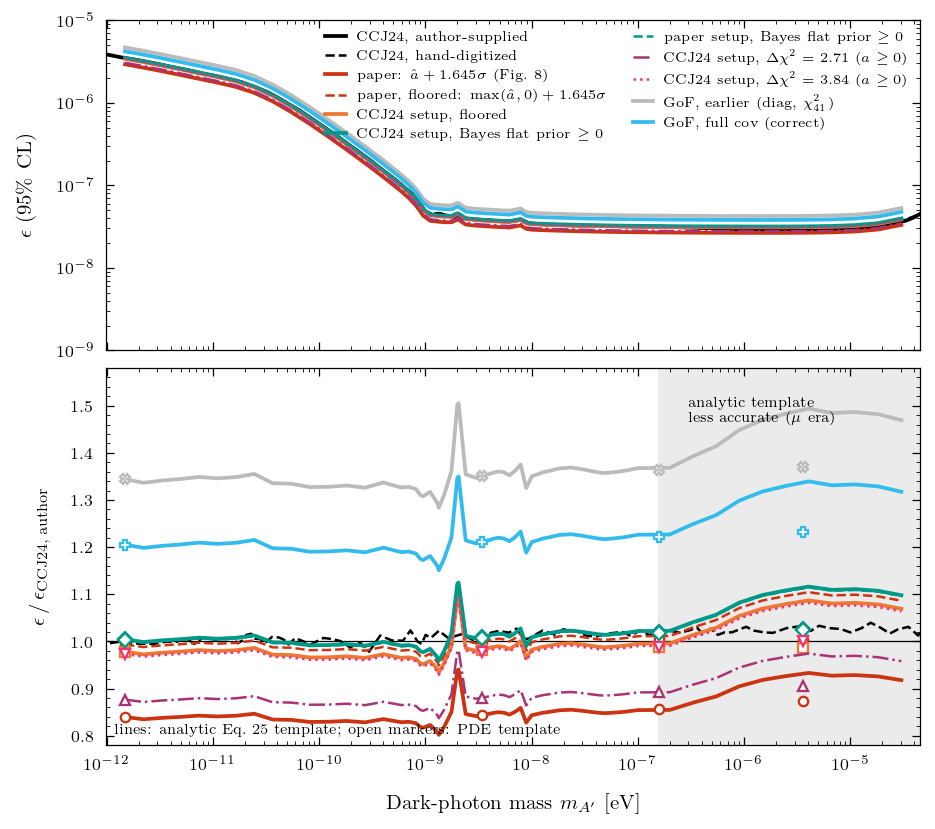

In [9]:
STYLE = {
    'paper':         dict(color=C['red'],     lw=LW_THICK, ls='-'),
    'paper_floor':   dict(color=C['red'],     lw=LW,       ls='--'),
    'ccj_floor':     dict(color=C['orange'],  lw=LW_THICK, ls='-'),
    'ccj_bayes':     dict(color=C['teal'],    lw=LW_THICK, ls='-'),
    'paper_bayes':   dict(color=C['teal'],    lw=LW,       ls='--'),
    'ccj_dchi2_271': dict(color=C['purple'],  lw=LW,       ls='-.'),
    'ccj_dchi2_384': dict(color=C['magenta'], lw=LW,       ls=':'),
    'gof_old':       dict(color=C['gray'],    lw=LW_THICK, ls='-'),
    'gof':           dict(color=C['cyan'],    lw=LW_THICK, ls='-'),
}
MARK = {'paper': 'o', 'paper_floor': 'o', 'ccj_floor': 's', 'ccj_bayes': 'D',
        'paper_bayes': 'D', 'ccj_dchi2_271': '^', 'ccj_dchi2_384': 'v',
        'gof_old': 'X', 'gof': 'P'}
LABEL = {k: lab for k, _, lab in STATS}

fig, (ax, axr) = plt.subplots(2, 1, figsize=(DOUBLE_COL, 6.4), sharex=True,
                              gridspec_kw={'height_ratios': [1.4, 1.6], 'hspace': 0.05})
ma = res_ana['m'].values
ax.loglog(ref_auth[:, 0], ref_auth[:, 1], color='k', lw=LW_THICK,
          label='CCJ24, author-supplied')
ax.loglog(ref_dig[:, 0], ref_dig[:, 1], color='k', lw=LW, ls='--',
          label='CCJ24, hand-digitized')
for key, st in STYLE.items():
    ax.loglog(ma, res_ana[key], **st, label=LABEL[key])
ax.set_ylabel(r"$\epsilon$ (95\% CL)")
ax.set_ylim(1e-9, 1e-5)
ax.legend(loc='upper right', fontsize=LEGEND_SIZE - 0.5, ncol=2, framealpha=0.95)

axr.axhline(1, color='k', lw=0.6)
axr.semilogx(ref_dig[:, 0], ref_dig[:, 1] / ref_eps(ref_auth, ref_dig[:, 0]),
             color='k', lw=LW, ls='--')
for key, st in STYLE.items():
    axr.semilogx(ma, res_ana[key] / res_ana['auth'], **st)
    axr.plot(res_pde['m'], res_pde[key] / res_pde['auth'], marker=MARK[key], ls='none',
             ms=4.5, mfc='white', mec=st['color'], mew=1.1)
axr.axvspan(1.6e-7, ma.max() * 1.5, color='0.92', zorder=0)
axr.text(3e-7, 1.52, 'analytic template\nless accurate ($\\mu$ era)',
         fontsize=LEGEND_SIZE, va='top')
axr.set_ylim(0.78, 1.58)
axr.set_xlim(ma.min() / 1.5, ma.max() * 1.5)
axr.set_xlabel(r"Dark-photon mass $m_{A'}$ [eV]")
axr.set_ylabel(r'$\epsilon\,/\,\epsilon_{\rm CCJ24,\,author}$')
axr.text(0.01, 0.03, 'lines: analytic Eq.~25 template; open markers: PDE template',
         transform=axr.transAxes, fontsize=LEGEND_SIZE)

for ext in ('pdf', 'png'):
    fig.savefig(FIG_DIR / f'dp_firas_limit_conventions.{ext}', bbox_inches='tight', dpi=200)
plt.show()

### Summary numbers

Ratio of each limit to the two CCJ24 curves: median and range over the analytic
grid for $m_{A'}\le1.6\times10^{-7}$ eV (where the analytic template is
accurate), and the values at the four PDE masses. The extremes of the range
come from the feature at $m_{A'}\approx2\times10^{-9}$ eV
($z_{\rm con}\approx1100$–$1500$, recombination). There the limit changes
sharply with mass, and our curve and the CCJ24 curves place the feature at
slightly different masses. Away from it the ratios are flat to about 2%.

In [10]:
rows = []
acc = res_ana[res_ana['m'] <= 1.6e-7]
for key, setup, lab in STATS:
    row = {'statistic': key, 'setup': setup}
    for ref in ('auth', 'dig'):
        r = acc[key] / acc[ref]
        row[f'/{ref} median'] = r.median()
        row[f'/{ref} range'] = f'{r.min():.3f}-{r.max():.3f}'
        rp = res_pde[key] / res_pde[ref]
        row[f'/{ref} PDE (4 masses)'] = ', '.join(f'{v:.3f}' for v in rp)
    rows.append(row)
summary = pd.DataFrame(rows).set_index('statistic')
pd.set_option('display.width', 250, 'display.max_colwidth', 40)
summary.round(3)

,setup,/auth median,/auth range,/auth PDE (4 masses),/dig median,/dig range,/dig PDE (4 masses)
statistic,,,,,,,
paper,paper,0.846,0.802-0.940,"0.839, 0.843, 0.856, 0.874",0.835,0.785-0.927,"0.840, 0.834, 0.838, 0.850"
paper_floor,paper,1.001,0.949-1.113,"0.994, 0.998, 1.005, 1.002",0.988,0.929-1.098,"0.995, 0.988, 0.984, 0.975"
ccj_floor,ccj24,0.985,0.934-1.096,"0.978, 0.983, 0.989, 0.986",0.972,0.914-1.080,"0.979, 0.972, 0.969, 0.960"
ccj_bayes,ccj24,1.012,0.959-1.125,"1.004, 1.009, 1.019, 1.026",0.998,0.939-1.110,"1.005, 0.998, 0.999, 0.998"
paper_bayes,paper,1.010,0.958-1.123,"1.003, 1.007, 1.017, 1.024",0.997,0.937-1.108,"1.004, 0.997, 0.996, 0.997"
ccj_dchi2_271,ccj24,0.883,0.837-0.982,"0.876, 0.881, 0.892, 0.905",0.871,0.819-0.968,"0.877, 0.871, 0.874, 0.880"
ccj_dchi2_384,ccj24,0.980,0.929-1.090,"0.973, 0.978, 0.989, 1.001",0.967,0.910-1.075,"0.974, 0.967, 0.969, 0.974"
gof_old,ccj24,1.354,1.284-1.506,"1.344, 1.350, 1.363, 1.371",1.336,1.256-1.485,"1.345, 1.336, 1.336, 1.334"
gof_diag_cal,ccj24,1.399,1.327-1.556,"1.389, 1.395, 1.408, 1.416",1.381,1.298-1.534,"1.390, 1.381, 1.380, 1.377"


## Why: the fluctuation $k = \hat a/\sigma_a$

The paper-to-floored ratio depends only on $k$. The top panel shows $k$ for
both setups. The bottom panel compares the prediction
$\sqrt{(k + 1.645)/1.645}$ with the measured ratio of the package's paper limit
(`FIRASData.profile_limit_floating_T`, nonlinear in $T$) to our floored limit
(linear GLS at $T_{\rm best}$).

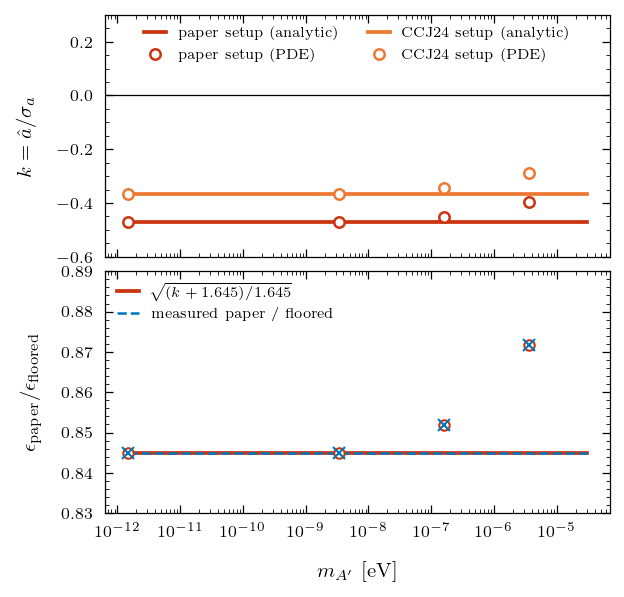

PDE k (paper setup): [-0.471, -0.471, -0.452, -0.395]
max |measured - predicted| at the PDE masses: 3.5e-07


In [11]:
fig, (ak, ar) = plt.subplots(2, 1, figsize=(DOUBLE_COL * 0.62, 4.4), sharex=True,
                             gridspec_kw={'hspace': 0.06})
for key, col, lab in (('k_paper', C['red'], 'paper setup'),
                      ('k_ccj', C['orange'], 'CCJ24 setup')):
    ak.semilogx(ma, res_ana[key], color=col, lw=LW_THICK, label=lab + ' (analytic)')
    ak.plot(res_pde['m'], res_pde[key], 'o', color=col, mfc='white', mew=1.2, ms=5,
            label=lab + ' (PDE)')
ak.axhline(0, color='k', lw=0.6)
ak.set_ylabel(r'$k = \hat a / \sigma_a$')
ak.set_ylim(-0.6, 0.3)
ak.legend(fontsize=LEGEND_SIZE, loc='upper center', ncol=2)

for df, st in ((res_ana, dict(color=C['red'], lw=LW_THICK)),
               (res_pde, dict(color=C['red'], marker='o', ls='none', mfc='white', ms=5))):
    kk = df['k_paper'].values
    pred = np.sqrt((kk + Z95) / Z95)
    meas = df['paper_pkg'] / df['paper_floor']
    if df is res_ana:
        ar.semilogx(df['m'], pred, **st, label=r'$\sqrt{(k+1.645)/1.645}$')
        ar.semilogx(df['m'], meas, color=C['blue'], lw=LW, ls='--',
                    label='measured paper / floored')
    else:
        ar.plot(df['m'], pred, **st)
        ar.plot(df['m'], meas, 'x', color=C['blue'], ms=6)
ar.set_ylabel(r'$\epsilon_{\rm paper}/\epsilon_{\rm floored}$')
ar.set_xlabel(r"$m_{A'}$ [eV]")
ar.set_ylim(0.83, 0.89)
ar.legend(fontsize=LEGEND_SIZE, loc='upper left')
for ext in ('pdf', 'png'):
    fig.savefig(FIG_DIR / f'dp_firas_limit_conventions_k.{ext}', bbox_inches='tight', dpi=200)
plt.show()

d = res_pde['paper_pkg'] / res_pde['paper_floor'] - np.sqrt((res_pde['k_paper'] + Z95) / Z95)
print('PDE k (paper setup):', np.round(res_pde['k_paper'], 3).tolist())
print(f'max |measured - predicted| at the PDE masses: {np.abs(d).max():.1e}')

## One mass in detail

At $m_{A'} = 3.4\times10^{-9}$ eV (PDE template, paper setup) we plot
$\chi^2(a) - \chi^2_{\rm min}$ against $a/\sigma_a$ and the flat-prior
posterior. The shaded region $a < 0$ is unphysical. Each vertical line is one
statistic's 95% limit.

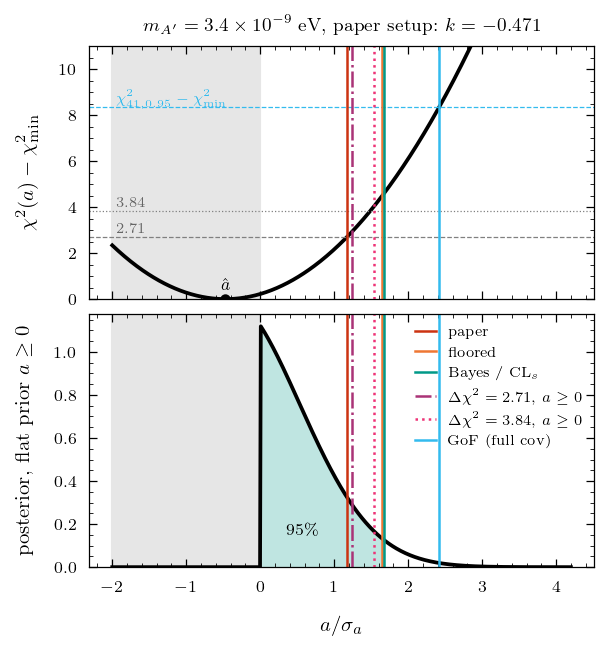

paper                        u = 1.174   eps ratio to paper = 1.000
floored                      u = 1.645   eps ratio to paper = 1.184
Bayes / CL$_s$               u = 1.675   eps ratio to paper = 1.194
$\Delta\chi^2=2.71$, $a\ge0$ u = 1.242   eps ratio to paper = 1.028
$\Delta\chi^2=3.84$, $a\ge0$ u = 1.545   eps ratio to paper = 1.147
GoF (full cov)               u = 2.420   eps ratio to paper = 1.435


In [12]:
p = pde[1]
fp = fit(p['tmpl'], **SETUPS['paper'])
k, c2min = fp['k'], fp['chi2_min']
aa = np.linspace(-2.0, 4.2, 600)

lines = [
    ('paper', u_paper(k), C['red'], '-'),
    ('floored', u_floor(k), C['orange'], '-'),
    ('Bayes / CL$_s$', u_bayes(k), C['teal'], '-'),
    (r'$\Delta\chi^2=2.71$, $a\ge0$', u_dchi2(k, 2.71), C['purple'], '-.'),
    (r'$\Delta\chi^2=3.84$, $a\ge0$', u_dchi2(k, 3.84), C['magenta'], ':'),
    ('GoF (full cov)', u_gof(k, c2min), C['cyan'], '-'),
]

fig, (a1, a2) = plt.subplots(2, 1, figsize=(DOUBLE_COL * 0.62, 4.6), sharex=True,
                             gridspec_kw={'hspace': 0.06})
a1.plot(aa, (aa - k) ** 2, color='k', lw=LW_THICK)
a1.axhline(2.71, color='0.5', lw=0.6, ls='--')
a1.axhline(3.84, color='0.5', lw=0.6, ls=':')
a1.axhline(CHI2_CRIT - c2min, color=C['cyan'], lw=0.6, ls='--')
a1.text(-1.95, 2.71 + 0.2, '2.71', fontsize=LEGEND_SIZE, color='0.4')
a1.text(-1.95, 3.84 + 0.2, '3.84', fontsize=LEGEND_SIZE, color='0.4')
a1.text(-1.95, CHI2_CRIT - c2min + 0.2, r'$\chi^2_{41,0.95} - \chi^2_{\rm min}$',
        fontsize=LEGEND_SIZE, color=C['cyan'])
a1.plot([k], [0], 'o', color='k', ms=4)
a1.text(k, 0.4, r'$\hat a$', ha='center', fontsize=LEGEND_SIZE + 1)
a1.set_ylim(0, 11)
a1.set_ylabel(r'$\chi^2(a) - \chi^2_{\rm min}$')

post = np.where(aa >= 0, norm.pdf(aa, k, 1), 0)
post /= np.trapz(post, aa)
a2.plot(aa, post, color='k', lw=LW_THICK)
ub = u_bayes(k)
sel = (aa >= 0) & (aa <= ub)
a2.fill_between(aa[sel], post[sel], color=C['teal'], alpha=0.25, lw=0)
a2.text(0.35, 0.15, '95\\%', fontsize=LEGEND_SIZE + 1)
a2.set_ylabel('posterior, flat prior $a\\ge0$')
a2.set_xlabel(r'$a / \sigma_a$')
a2.set_ylim(0, None)

for ax_ in (a1, a2):
    ax_.axvspan(aa[0], 0, color='0.9', zorder=0)
    for lab, u, col, ls in lines:
        ax_.axvline(u, color=col, lw=LW, ls=ls, label=lab)
a2.legend(fontsize=LEGEND_SIZE, loc='upper right', framealpha=0.95)
a1.set_title(rf"$m_{{A'}} = 3.4\times10^{{-9}}$ eV, paper setup: $k = {k:.3f}$",
             fontsize=LEGEND_SIZE + 2)
for ext in ('pdf', 'png'):
    fig.savefig(FIG_DIR / f'dp_firas_limit_conventions_dchi2.{ext}', bbox_inches='tight', dpi=200)
plt.show()
for lab, u, _, _ in lines:
    print(f'{lab:28s} u = {u:.3f}   eps ratio to paper = {np.sqrt(u / u_paper(k)):.3f}')

## One change at a time

Starting from the CCJ24 setup with a floor, we switch one ingredient at a time
until we reach the paper statistic. The PDE templates are used at all four
masses. "step" is the factor in $\epsilon$ from the previous row. The last two
rows branch off: they keep the floor and change only the covariance or apply
all paper inputs.

In [13]:
WALK = [
    ('S0 CCJ24 setup, floored', dict(cov='diag', column=3, float_T=False), True),
    ('S1 drop the floor', dict(cov='diag', column=3, float_T=False), False),
    ('S2 + full covariance', dict(cov='full', column=3, float_T=False), False),
    ('S3 + column 2 data', dict(cov='full', column=2, float_T=False), False),
    ('S4 + floating T (= paper)', dict(cov='full', column=2, float_T=True), False),
    ('A1 CCJ24 setup + full cov, floored', dict(cov='full', column=3, float_T=False), True),
    ('A2 paper setup, floored', dict(cov='full', column=2, float_T=True), True),
]
rows = []
for p in pde:
    prev = None
    for name, kw, floor in WALK:
        f = fit(p['tmpl'], **kw)
        u = u_floor(f['k']) if floor else u_paper(f['k'])
        e = np.sqrt(u * f['s'] / p['gpe2'])
        step = e / prev if (prev is not None and name[0] == 'S') else np.nan
        if name[0] == 'S':
            prev = e
        rows.append({'m [eV]': f"{p['m']:.1e}", 'step': name, 'k': f['k'],
                     'eps': e, 'factor': step,
                     '/author': e / ref_eps(ref_auth, p['m']),
                     '/digitized': e / ref_eps(ref_dig, p['m'])})
walk = pd.DataFrame(rows)
walk.pivot_table(index='step', columns='m [eV]', values=['/author', 'factor'],
                 sort=False).round(3)

/author                          factor                        
m [eV]                             1.5e-12 3.4e-09 1.6e-07 3.6e-06 1.5e-12 3.4e-09 1.6e-07 3.6e-06
step                                                                                              
S0 CCJ24 setup, floored              0.978   0.983   0.989   0.986     NaN     NaN     NaN     NaN
S1 drop the floor                    0.863   0.867   0.879   0.896   0.882   0.882   0.889   0.909
S2 + full covariance                 0.857   0.861   0.873   0.892   0.993   0.993   0.993   0.995
S3 + column 2 data                   0.839   0.843   0.856   0.874   0.980   0.980   0.980   0.980
S4 + floating T (= paper)            0.839   0.843   0.856   0.874   1.000   1.000   1.000   1.000
A1 CCJ24 setup + full cov, floored   0.994   0.998   1.005   1.002     NaN     NaN     NaN     NaN
A2 paper setup, floored              0.994   0.998   1.005   1.002     NaN     NaN     NaN     NaN

In [14]:
walk.pivot_table(index='step', columns='m [eV]', values=['k', '/digitized'], sort=False).round(3)

k                         /digitized                        
m [eV]                             1.5e-12 3.4e-09 1.6e-07 3.6e-06    1.5e-12 3.4e-09 1.6e-07 3.6e-06
step                                                                                                 
S0 CCJ24 setup, floored             -0.365  -0.365  -0.344  -0.287      0.979   0.972   0.969   0.960
S1 drop the floor                   -0.365  -0.365  -0.344  -0.287      0.863   0.857   0.862   0.872
S2 + full covariance                -0.422  -0.422  -0.401  -0.343      0.858   0.852   0.856   0.868
S3 + column 2 data                  -0.471  -0.471  -0.452  -0.395      0.840   0.834   0.838   0.850
S4 + floating T (= paper)           -0.471  -0.471  -0.452  -0.395      0.840   0.834   0.838   0.850
A1 CCJ24 setup + full cov, floored  -0.422  -0.422  -0.401  -0.343      0.995   0.988   0.984   0.975
A2 paper setup, floored             -0.471  -0.471  -0.452  -0.395      0.995   0.988   0.984   0.975

## Conclusions

**What causes the gap.** The floor. FIRAS fluctuates low along the
dark-photon shape: $k = \hat a/\sigma_a = -0.47$ in the paper setup below
$10^{-7}$ eV, rising to $-0.40$ at $3.6\times10^{-6}$ eV. The paper's
unfloored limit is therefore $\sqrt{(k+1.645)/1.645} = 0.85$–$0.87$ of the
floored one in $\epsilon$, and this formula matches the measured ratio to
numerical precision. Flooring the paper statistic lands on the author-supplied
CCJ24 curve to within 1% at the PDE masses.

**What does not.**

- *Floating $T$.* $T_{\rm best} = 2.72502$–$2.72503$ K, and the step from fixed
  $T_0$ to floating $T$ is 1.000. For a Gaussian likelihood that is linear
  in its nuisance parameters, profiling and projection are the same operation.
  The earlier notebook's attribution of the gap to floating-$T$ profiling is
  wrong.
- *Projecting the nuisance templates from the model only, or from data and
  model.* The $\Delta\chi^2$ curves are identical because
  $\vec d\cdot\vec S_\perp = \vec d_\perp\cdot\vec S_\perp$.
- *Covariance and data column.* Without a floor they give factors of 0.99 and
  0.98. With a floor, $\sigma_a$ does not depend on the data, so the column
  drops out and the full covariance moves the limit by +1.6%.

**Which CCJ24 reading fits.** Two readings of their "simple Gaussian
likelihood" reproduce the published curve: a floored best fit with diagonal
errors (0.978–0.989 of the author-supplied curve at the PDE masses), and a
flat prior on $\gamma_{\rm con}\ge0$ (1.004–1.026 of it, and 0.998–1.005 of
the hand-digitized one). Our two copies of the CCJ24 curve differ by up to 3.3%
in this range, about the size of the gap between the two readings, so the
data we have cannot pick one. The GoF readings do not fit: the earlier version
gives 1.34–1.37 times the author-supplied curve and the corrected one 1.21–1.23.

**The GoF implementation.** The earlier `gof_limit` has the right form for a
GoF test: $\chi^2(a)$ at fixed $a$ against the 95th percentile of
$\chi^2_{41}$. It fits the nuisance parameters only by accident, because FIRAS
column 3 is already orthogonal to $G_{\rm bb}$ and dust
($|\vec d_\parallel|^2 = 0.01$). Its $\chi^2_{41}$ threshold is slightly wrong,
because with diagonal errors on correlated data the 95th percentile is 58.4,
not 56.9. The corrected version (full covariance, nuisance fitted explicitly)
gives limits 10% lower in $\epsilon$ than the earlier version, but they are
still 20% weaker than CCJ24 and 43% weaker than the paper's limit. FIRAS's $\chi^2_{\rm min}/{\rm dof} = 1.2$ is
ordinary, so the weakness comes from the test spreading its power over 41
directions, not from an unusually good fit.

**Which statistic to use.** $\gamma_{\rm con}$ is non-negative. The unfloored
one-sided limit has correct frequentist coverage, but when the data fluctuate
low it excludes signals the experiment cannot detect: here it claims 15%
more reach in $\epsilon$ than the FIRAS sensitivity supports. The standard
remedies are CL$_s$ (Read 2002, J. Phys. G 28, 2693), which equals the flat-prior
Bayesian limit for this Gaussian case; the power-constrained or bounded
likelihood-ratio limits of Cowan, Cranmer, Gross & Vitells (2011,
arXiv:1105.3166); and the Feldman–Cousins unified intervals (1998, Phys. Rev.
D 57, 3873). Any of these, or a plain floor, would put Fig. 8 on the CCJ24
curve to within the 3.3% scatter between the two copies of that curve.